In [1]:
# import des bibliothèques Python utiles:
import numpy as np
import matplotlib.pyplot as plt

# "magic function" Jupyter pour l'affichage des graphiques dans le carnet:
%matplotlib inline



**Modèle nonlinéaire**

Nous allons  construire un modèle  polynomial de degré $n$ (donc non linéaire):

Il y a $m$ données. soit chaque donnée à 1 seul attribut (propriété)

Régression linéaire consiste à construire une fonction $ f(x)= a x + b$ (déterminer les paramètres a et b) qui minimise la fonction de perte:

$$
\frac{1}{m}\sum_1^m (y_i-f(x_i))^2= \frac{1}{m}\sum_1^m (\epsilon_i) ^2
$$
où $y_i$ l'étiquette pour la donnée $x_i$.

On peut écrire $ f(x)= \sum_{j=0}^1 {a_j x^j}$
où  $a_0$ est $b$.

Soit le dégré du polynôme $n=3$, il y aurait 3 attributs pour chaque donnée $x_i$:
$x_i; x_i^2; x_i^3$. La fonction à estimer:

$ f(x)= \sum_{j=0}^3 {a_j x^j}= a_0+a_1x+a_2 x^2 + a_3 x^3$


 

Nous faisons en fait la regression linéaire en considérant  plusieurs attributs (polynôme de degré n).

On minimise sur $m$ données
$$ \sum_{i=1}^m (\sum_{j=0}^n a_j (x_i)^j - y_i)^2 $$





In [2]:

#On reprend l'exemple précédent 

x_mod = np.linspace(0., 1.5, 150)

y_m = np.exp(3*x_mod)


X_m = x_mod[:,np.newaxis]

In [3]:
"""Nous générons  maintenant les données que l'on va utiliser 
pour faire l'apprentissage  en ajoutant du bruit aléatoire 
(qui suit la loi normale)
"""


x_data = np.array([0, .1, .2, .5, .8, .9, 1, 1.2, 1.5])

#nous changeons la taille de données pour pouvoir utiliser dans ScikitLearn
X_d = x_data.reshape(len(x_data),1) 


np.random.seed(44)
y_d = np.exp(3*X_d) + 5.0 * np.random.randn(len(X_d),1)

#y_d sont les étiquettes pour les données X_d

print("données X_d:")
print(X_d)
print("données y_d:")
print(y_d)


données X_d:
[[0. ]
 [0.1]
 [0.2]
 [0.5]
 [0.8]
 [0.9]
 [1. ]
 [1.2]
 [1.5]]
données y_d:
[[-2.75307359]
 [ 7.93164543]
 [ 8.05281894]
 [-3.54288964]
 [ 3.68245799]
 [ 6.30437944]
 [29.37945538]
 [37.03617433]
 [89.75552032]]


In [4]:
# On importe le modèle  
import sklearn.linear_model as lm

# On crée un objet scikit-learn pour la régression linéaire:
lr = lm.LinearRegression()

In [5]:
# modèle polynomial avec $n=2$# 

X_d2 = np.power(X_d,2)

X_m2 = np.power(X_m,2)


# Créer une matrice de données avec 2 attributs
#X_n2 = np.column_stack((X_d,X_d2))
X_n2 = np.hstack((X_d,X_d2))
# Créer une matrice du modèle prédictif avec 2 attributs
X_mn = np.hstack((X_m,X_m2))

#par la compréhesion des listes
#test = [ np.array([X_d[i][0],X_d2[i][0]]) for i in range(X_d.size)]
#print(test)

print("régression: polynome degré 2")
lrp2 = lm.LinearRegression()
lrp2.fit(X_n2,y_d)  
#lrp2.fit(test,y_d)  

print(lrp2.intercept_)
print(lrp2.coef_)

y_pred_lr2 = lrp2.predict(X_mn) 


régression: polynome degré 2
[8.26165798]
[[-64.05240705  77.42492089]]


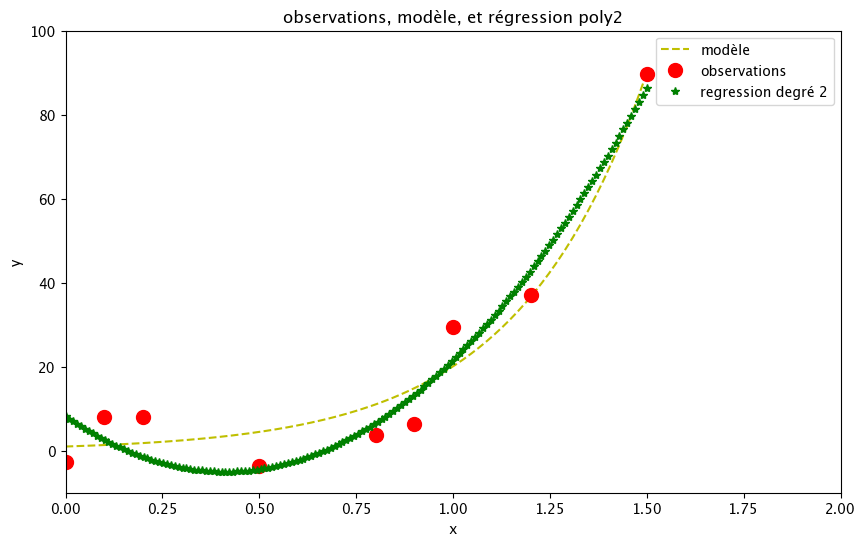

In [6]:
# représentation graphique:
plt.figure(figsize=(10,6))
plt.plot(X_m, y_m, '--y')
plt.plot(X_d, y_d, 'or', ms=10)
#plt.plot(X_m, y_pred_lr, '-g')
plt.plot(X_m, y_pred_lr2, '*g')
plt.xlim(0, 2.0)
plt.xlabel("x")
plt.ylim(-10, 100)
plt.ylabel("y")
plt.title('observations, modèle, et régression poly2')
plt.legend(["modèle","observations","regression degré 2"]);
plt.show()



In [7]:
# Nous calculons la fiabilité du modèle de regréssion
# Nous importons les modules 

from sklearn.metrics import mean_squared_error 
from sklearn.metrics import r2_score 


In [8]:
print("  MSE poly. 2 pour Xd= {} ".format(mean_squared_error(y_d,lrp2.predict(X_n2))))

print("r2score  poly. 2 pour Xd= {} ".format(r2_score(y_d,lrp2.predict(X_n2))))

  MSE poly. 2 pour Xd= 44.86637100703613 
r2score  poly. 2 pour Xd= 0.9427749490889867 


In [9]:
print("  MSE poly. 2 pour Xm= {} ".format(mean_squared_error(y_m,y_pred_lr2)))

print("r2score  poly. 2 pour Xm= {} ".format(r2_score(y_m,y_pred_lr2)))

  MSE poly. 2 pour Xm= 31.69348918272395 
r2score  poly. 2 pour Xm= 0.9394387792214274 


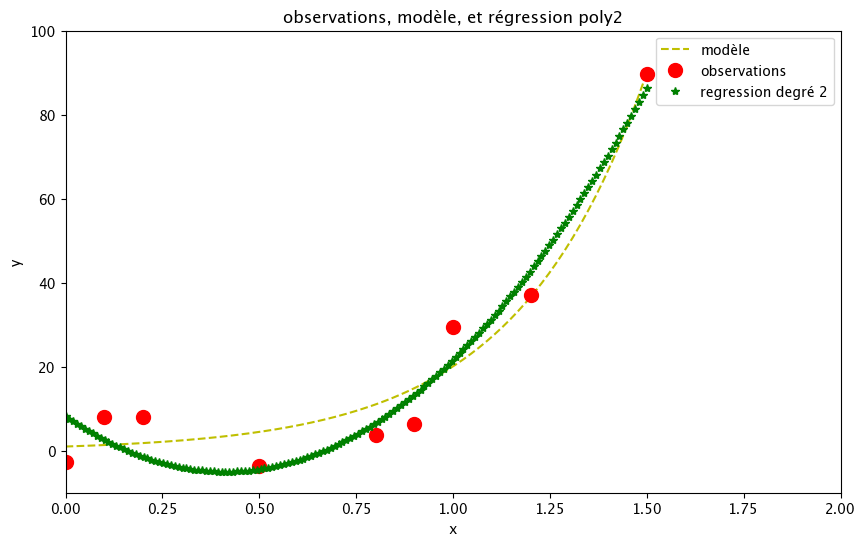

In [10]:
# Nous pouvons faire en utilisant Polynomial Features

from sklearn.preprocessing import PolynomialFeatures

# perform a polynomial features transform of the dataset
trans = PolynomialFeatures(degree=2)
data = trans.fit_transform(X_d)
lrp2 = lm.LinearRegression()
lrp2.fit(data,y_d)

dataX_m=trans.fit_transform(X_m)

dataX_d=trans.fit_transform(X_d)

y_m_pred_lr2 = lrp2.predict(dataX_m) 
y_d_pred_lr2 = lrp2.predict(dataX_d) 

# représentation graphique:
plt.figure(figsize=(10,6))
plt.plot(X_m, y_m, '--y')
plt.plot(X_d, y_d, 'or', ms=10)
#plt.plot(X_m, y_pred_lr, '-g')
plt.plot(X_m, y_pred_lr2, '*g')
plt.xlim(0, 2.0)
plt.xlabel("x")
plt.ylim(-10, 100)
plt.ylabel("y")
plt.title('observations, modèle, et régression poly2')
plt.legend(["modèle","observations","regression degré 2"]);
plt.show()


Calculez   erreur (mean_squared_error), r2score pour les observations (X_d) pour ce modèle

In [11]:
print("MSE poly. 2 pour les X_d = {} ".format(mean_squared_error(y_d,lrp2.predict(dataX_d))))

print("r2score poly. 2  pour les observations= {} ".format(r2_score(y_d,lrp2.predict(dataX_d))))

MSE poly. 2 pour les X_d = 44.86637100703612 
r2score poly. 2  pour les observations= 0.9427749490889867 


Calculez  erreur (mean_squared_error) erreur, r2score pour les données X_m pour ce modèle

In [12]:
print("  MSE poly. 2 pour Xm= {} ".format(mean_squared_error(y_m,y_pred_lr2)))

print("r2score  poly. 2 pour Xm= {} ".format(r2_score(y_m,y_pred_lr2)))

  MSE poly. 2 pour Xm= 31.69348918272395 
r2score  poly. 2 pour Xm= 0.9394387792214274 



Comparez les qualités des résultats obtenus par le modèle linéaire et par le modèle non linéaire de degré n pour X_d et X_m. Que constatez-vous?


Nous définissons maintenant un modèle non linéaire de dégré 7

In [13]:
#On fait la regression avec un polynôme de degré 7

X_d3=np.power(X_d,3)
X_d4=np.power(X_d,4)
X_d5=np.power(X_d,5)
X_d6=np.power(X_d,6)
X_d7=np.power(X_d,7)

X_m3=np.power(X_m,3)
X_m4=np.power(X_m,4)
X_m5=np.power(X_m,5)
X_m6=np.power(X_m,6)
X_m7=np.power(X_m,7)

# modèle polynomial avec $n=7$
lrp7 = lm.LinearRegression()
X_n7 = np.hstack((X_d,X_d2,X_d3,X_d4,X_d5,X_d6,X_d7))
lrp7.fit(X_n7,y_d)

print("régresion: polynome degré 7")
print(lrp7.intercept_)                   
print(lrp7.coef_)
y_lr7= lrp7.predict(np.hstack((X_m,X_m2,X_m3,X_m4,X_m5,X_m6,X_m7)))

régresion: polynome degré 7
[-2.90991516]
[[   262.18055636  -2121.484714     7975.9879919  -16609.0592596
   18841.43374873 -10659.29561437   2339.70351326]]


Dessinez le modèle de poly. 7

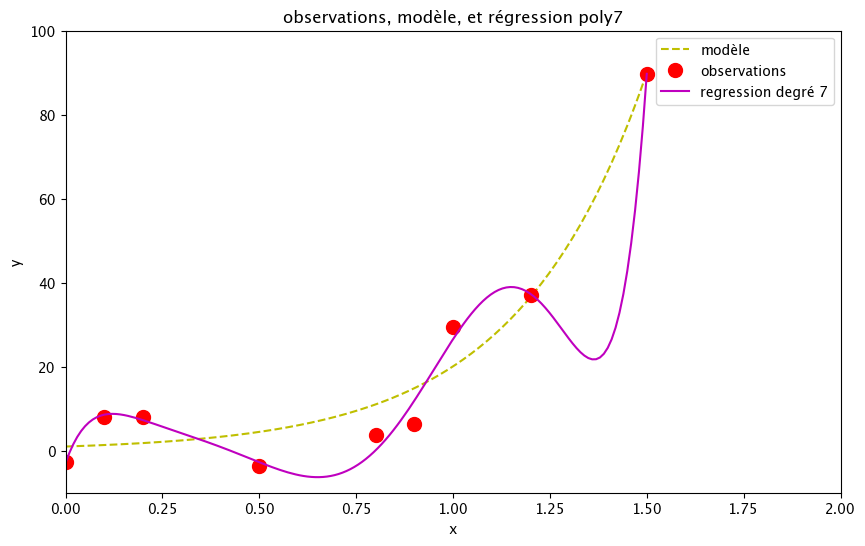

In [14]:
# représentation graphique:
plt.figure(figsize=(10,6))
plt.plot(X_m, y_m, '--y')
plt.plot(X_d, y_d, 'or', ms=10)
#plt.plot(X_m, y_pred_lr, '-g')
#plt.plot(X_m, y_pred_lr2, '*y')
plt.plot(X_m, y_lr7, '-m')
plt.xlim(0, 2.0)
plt.xlabel("x")
plt.ylim(-10, 100)
plt.ylabel("y")
plt.title('observations, modèle, et régression poly7')
plt.legend(["modèle","observations",
            "regression degré 7"]);
plt.show()




Calculez MSE, r2score pour X_d pour le modèle non linéaire de degré 7

In [15]:
print(" poly 7, MSE X_d = {} ".format(mean_squared_error(y_d, lrp7.predict(X_n7))))

print(" poly 7 modele, r2_score pour X_d= {} ".format(r2_score(y_d,lrp7.predict(X_n7) )))

 poly 7, MSE X_d = 6.012509233616264 
 poly 7 modele, r2_score pour X_d= 0.992331313202428 


Calculez MSE, r2score pour X_m pour le modèle non linéaire de degré 7

In [16]:
print(" poly 7, MSE pour X_m = {} ".format(mean_squared_error(y_m, y_lr7)))

print(" poly 7 modele, r2_score pour X_m= {} ".format(r2_score(y_m, y_lr7)))

 poly 7, MSE pour X_m = 210.4970514680204 
 poly 7 modele, r2_score pour X_m= 0.5977735889634319 


On voit que le modèle de degré 7 "colle" bien aux données   observés, X_d (MSE 6,01; r2-score 0.99). Par contre  les résultats sont mauvais pour  prédire le modèle génératif, X_m. On dit qu'il y a  eu **surapprentissage**. 

A l'inverse, le modèle de la régression linéaire simple est dans une situation de **sous-apprentissage**,  MSEs, r2scores  sont mauvais pour ce modèle

Pour ce cas, le modèle de degré 2 donnent de bonnes résultats pour X_m et X_d

Trouvez l'étiquette  pour X=1.4 pour tous les modèles (linéaire, poly. 2, poly 7)

**RIDGE REGRESSION**

Il y aussi différentes modèles de regression. Nous présentons Ridge regression

Pour ce modèle, on minimise 
$$ \sum_{i=1}^m (\sum_{j=0}^n a_j (x_d[i])^j - y_d[i])^2 + C \sum_{j=0}^n a_j$$

$C$ est un paramètre positif. La régression linéaire classique correspond au cas particulier  $𝐶=0$

 

In [17]:
#Nous construisons les mêmes modèles par regression Ridge

ridge = lm.Ridge()
ridge.fit(X_d,y_d)
print("ridge regression, polynome degré 1")
print(ridge.intercept_)
print(ridge.coef_)
y_lrr = ridge.predict(X_m)



ridge2 = lm.Ridge()
ridge2.fit(X_n2,y_d)
print("ridge regression, polynome degré 2")
print(ridge2.intercept_)
print(ridge2.coef_)
y_lrr2 = ridge2.predict(np.hstack((X_m,X_m2)))


ridge7 = lm.Ridge()
ridge7.fit(X_n7,y_d)
print("ridge regression, polynome degré 7")
print(ridge7.intercept_)
print(ridge7.coef_)
y_lrr7 = ridge7.predict(np.hstack((X_m,X_m2,X_m3,X_m4,X_m5,X_m6,X_m7)))

ridge regression, polynome degré 1
[-1.4549022]
[[30.47429168]]
ridge regression, polynome degré 2
[-2.90610433]
[[ 4.84512584 26.70211915]]
ridge regression, polynome degré 7
[2.1416711]
[[ 0.38921314  1.97532144  3.41434237  4.06193114  3.81519816  2.47770629
  -0.34610814]]


Présentez les modèles dans une courbe

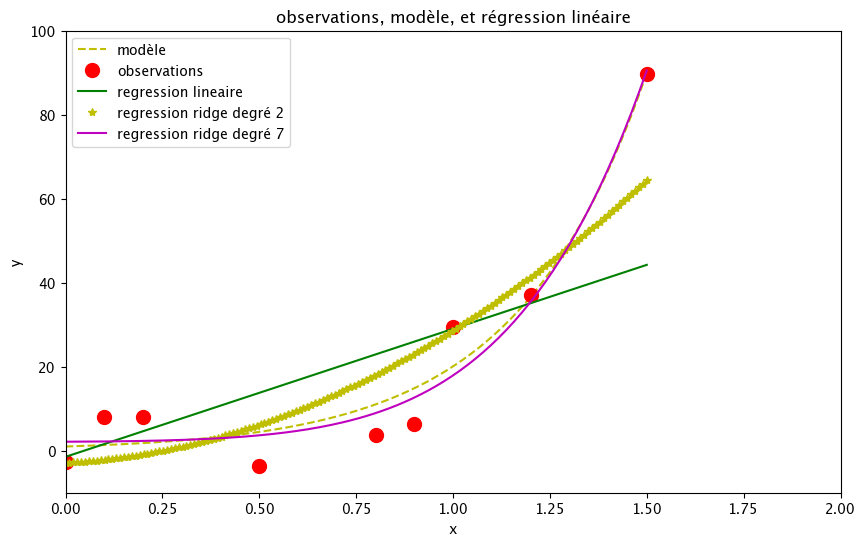

In [18]:
# représentation graphique:
plt.figure(figsize=(10,6))
plt.plot(X_m, y_m, '--y')
plt.plot(X_d, y_d, 'or', ms=10)
plt.plot(X_m,y_lrr, '-g')
plt.plot(X_m,y_lrr2, '*y')
plt.plot(X_m, y_lrr7, '-m')
plt.xlim(0, 2.0)
plt.xlabel("x")
plt.ylim(-10, 100)
plt.ylabel("y")
plt.title('observations, modèle, et régression linéaire')
plt.legend(["modèle","observations","regression lineaire","regression ridge degré 2", 
            "regression ridge degré 7"]);
plt.show()



In [19]:
print(" poly 7 LRR,  MSE pour X_d= {} ".format(mean_squared_error(y_d, ridge7.predict(X_n7))))

print(" poly 7 LRR, r2score X_d= {} ".format(r2_score(y_d, ridge7.predict(X_n7))))

 poly 7 LRR,  MSE pour X_d= 38.20280491015271 
 poly 7 LRR, r2score X_d= 0.9512740298165824 


In [20]:
print(" poly7, LRR, MSE  pour X_m = {} ".format(mean_squared_error(y_m, y_lrr7)))

print(" poly7, LRR, r2_score pour X_m = {} ".format(r2_score(y_m, y_lrr7)))

 poly7, LRR, MSE  pour X_m = 1.72842689646189 
 poly7, LRR, r2_score pour X_m = 0.9966972508999321 


In [21]:
print(" poly2 LRR,  MSE pour X_d = {} ".format(mean_squared_error(y_d, ridge2.predict(X_n2))))

print(" poly2 LRR,  r2score pour X_d = {} ".format(r2_score(y_d, ridge2.predict(X_n2))))

 poly2 LRR,  MSE pour X_d = 158.26515751476958 
 poly2 LRR,  r2score pour X_d = 0.7981398652723238 


In [22]:
print(" poly2 LRR, pour X_m MSE = {} ".format(mean_squared_error(y_m, y_lrr2)))

print(" poly2 LRR,  rscore  pour X_m = {} ".format(r2_score(y_m, y_lrr2)))

 poly2 LRR, pour X_m MSE = 48.959106586852585 
 poly2 LRR,  rscore  pour X_m = 0.9064469283885512 


In [23]:
print(" LRR,  MSE pour  X_d= {} ".format(mean_squared_error(y_d, ridge.predict(X_d))))

print(" LRR,  r2score  pour X_d = {} ".format(r2_score(y_d, ridge.predict(X_d))))

 LRR,  MSE pour  X_d= 353.8588610348557 
 LRR,  r2score  pour X_d = 0.5486688385192298 


In [24]:
print(" LRR,  MSE  pour X_m= {} ".format(mean_squared_error(y_m, y_lrr)))

print(" LRR  rscore  pour X_m= {} ".format(r2_score(y_m, y_lrr)))

 LRR,  MSE  pour X_m= 169.0329055347186 
 LRR  rscore  pour X_m= 0.6770049819408404 


Que constatez-vous?